# İlk Tekrarlayan Sinir Ağınız (RNN)

🙌 RNN'lere hoş geldiniz! Önceki derste CNN'leri görsellerle (uzamsal veri) kullandıktan sonra, şimdi zamana bağlı verilerle (***zamansal veri***) çalışacaksınız.

🎯 Bu ısınma egzersizinin hedefleri:

1. Zamansal verinin ne olduğunu anlamak
2. İlk Tekrarlayan Sinir Ağlarınızı oluşturmak

_Not: Google Colab kullanmanıza gerek yok ❌_

## (1) 📚 Veri Seti

_Uyarı: Bu bölümde kendinizin kodlayacağı bir şey yok, dikkatli okuyun ve hücreleri çalıştırın. RNN ve LSTM modellerine odaklanmanızı istiyoruz, Python sorularına değil_ 😉

🔢 Bir şirketteki çalışanlar hakkında bazı verilere erişimimiz olduğunu düşünelim.

In [ ]:
import numpy as np

X = np.load('X.npy')
y = np.load('y.npy')

In [ ]:
X.shape, y.shape

((25000, 10, 3), (25000,))

☝️ Veri seti, **25.000 çalışanın istihdam durumunun yıl bazında evrimini** tanımlamaktadır: her dizi, 10 ardışık yılı içerir ve her yıl 3 bileşenden oluşan bir iş durumunu tanımlar:
- maaş,
- sorumluluğu altındaki kişi sayısı,
- şirketin büyüklüğü.

🕵🏻 Veri setini biraz daha iyi anlamak için, ilk çalışanın verilerine bakalım.

In [ ]:
import pandas as pd

employee_0 = pd.DataFrame(X[0],
                          columns=['salary',
                                   'responsibility',
                                   'company_size'])
round(employee_0,2)

,salary,responsibility,company_size
0,0.80,10.73,102.0
1,0.50,10.73,102.0
2,0.60,10.73,102.0
3,0.71,10.73,130.0
4,0.94,10.73,130.0
5,1.05,10.73,130.0
6,1.12,32.00,108.0
7,4.87,32.00,108.0
8,4.97,33.00,108.0
9,5.20,39.00,108.0


🎯 Bu egzersizdeki amaç, bu 25.000 çalışanın her birinin geçmiş gözlemlerine dayalı olarak 11. yıldaki aylık maaşını tahmin etmektir.

In [ ]:
# Örneğin, ilk çalışan şirketteki 11. yılında
# ayda 6.499 bin USD kazanıyor
y[0]

6.499

📈 Maaşların, sorumluluğu altındaki kişi sayısının ve şirket büyüklüğünün yıllar boyunca nasıl evrimleştiğini daha iyi anlamanıza yardımcı olmak için aşağıdaki hücreyi çalıştırabilirsiniz. Bu üç değişken arasında görsel olarak bazı korelasyonlar tespit edebiliyor musunuz?

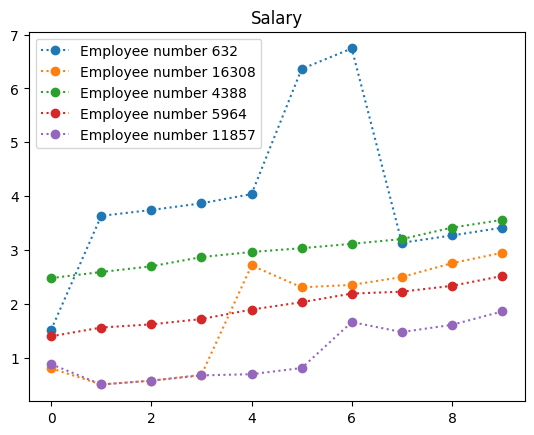

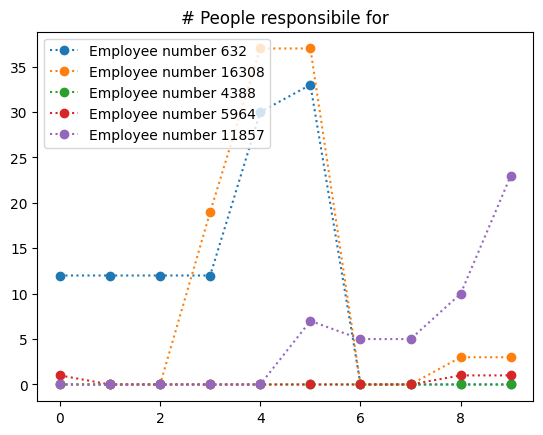

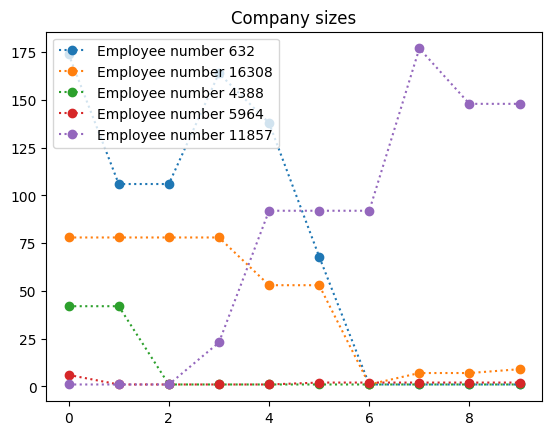

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

number_of_employees = len(X)

### Rastgele çalışan seçimi
##### Çalışanlar rastgele seçildiği için, bu hücreyi birkaç kez çalıştırabilirsiniz!

number_of_randomly_selected_employees = 5

random_selection = np.random.randint(0,
                                     number_of_employees,
                                     number_of_randomly_selected_employees)


### Seçilen çalışanlar için veri görselleştirme

plt.title('Maaş')
for r in random_selection:
    plt.plot(X[r, :, 0],label=f"Çalışan numarası {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('Sorumlu olduğu kişi sayısı')
for r in random_selection:
    plt.plot(X[r, :, 1],label=f"Çalışan numarası {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('Şirket büyüklükleri')
for r in random_selection:
    plt.plot(X[r, :, 2],label=f"Çalışan numarası {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

🕵🏻 **Veri Keşfi** 🕵🏻 Gözlemlerin değişkenliğini daha iyi anlamak için aşağıdakilerin dağılımına bakın:
* 10. yıldaki tüm maaşlar, 
* sorumluluğu altındaki kişiler, 
* ve şirket büyüklükleri

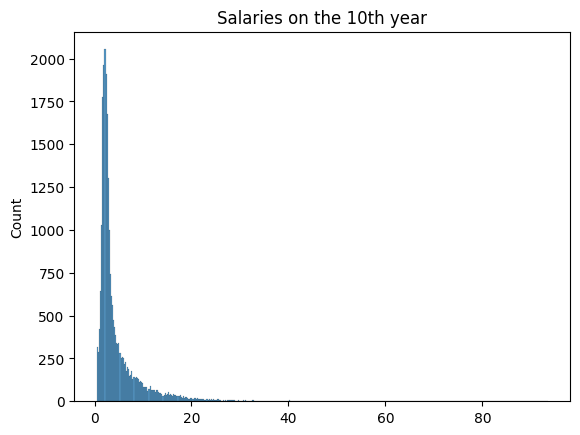

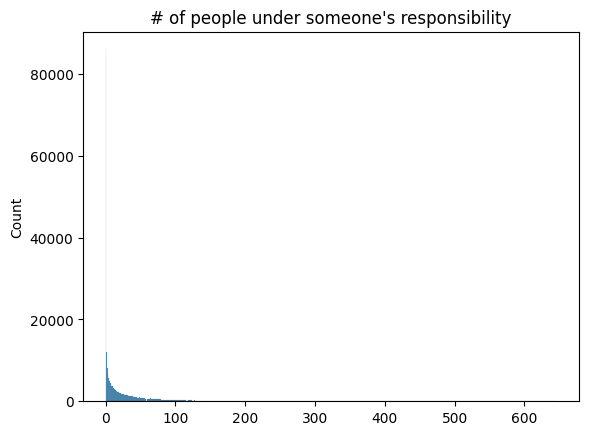

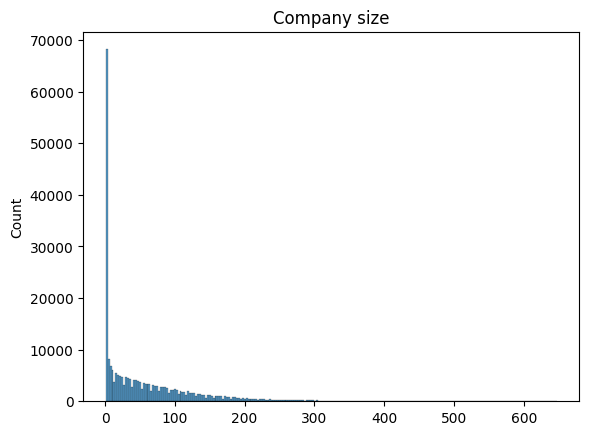

In [ ]:
import seaborn as sns

plt.title("10. yıldaki maaşlar")
sns.histplot(X[:, -1, 0].flatten()) # tüm çalışanlar, son yıl, özellik #0 = maaşlar
plt.show()

plt.title("Sorumlu olunan kişi sayısı")
sns.histplot(X[:, :, 1].flatten()) # tüm çalışanlar, tüm yıllar, özellik #1 = sorumluluklar
plt.show()

plt.title("Şirket büyüklüğü")
sns.histplot(X[:, :, 2].flatten()) # tüm çalışanlar, tüm yıllar, özellik #2 = şirket büyüklüğü
plt.show()

✂️ **Ayırma yöntemi** Veri setini eğitim ve test setine bölelim (80/20)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# 25.000 çalışanı train_test_split ile ayırıyoruz!

## (2) 💻 Basit RNN

🤗 Artık bu şirketin veri setine aşina olduğunuza göre, ilk Tekrarlayan Sinir Ağınızı oluşturacaksınız. Basit bir mimariye başlayalım.

❓ **Soru** ❓ Aşağıdakileri içeren bir model yazın: 
- eğitim setine uyarlanmış bir ***Normalization*** katmanı
- 20 *birim* içeren bir ***SimpleRNN*** katmanı (`tanh`'ın Tekrarlayan Katman için aktivasyon fonksiyonu olarak daha uygun olduğunu unutmayın)
- 10 nöron içeren bir ***Dense*** katmanı
- görevinize özel bir ***Dense*** katmanı (= bir maaşı ***tahmin etmek*** için)

👩🏻‍🏫 Unutmayın: İlk katmandan önce bir `keras.Input` eklemeyi unutmayın.

In [ ]:
from keras import Sequential, Input
from keras.layers import Dense, SimpleRNN, Flatten, Normalization

In [ ]:
# Normalization Katmanını X_train'e uyarlama
normalizer = Normalization()
normalizer.adapt(X_train)

# RNN mimarisini oluşturma
model = Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(normalizer)
model.add(SimpleRNN(units=20, activation='tanh'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))

❓ **Soru**: RNN'inizin kaç eğitilebilir parametresi var ❓

In [ ]:
# RNN özetini yazdırma
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 10, 3)          │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708 (2.77 KB)

 Trainable params: 701 (2.74 KB)

 Non-trainable params: 7 (32.00 B)

❓ **Soru** ❓ Parametre sayısını manuel olarak yeniden hesaplamaya çalışın.

<details>
    <summary><i>Cevap</i></summary>


- <u> Normalization Katmanı</u>: 
    - Bu katman normalize edilecek $\color{red}{n_x = 3} $ özelliğe (maaş, sorumluluk, şirket büyüklüğü) sahiptir. Her biri için <font color=blue>_ortalama_</font> ve <font color=blue>_standart sapma_</font> hesaplanması gerekir. Dolayısıyla $\color{red}{n_x = 3} \times \color{blue}{2} = 6$ eğitilmeyen parametremiz var. 7. parametre başlangıçta 0'a ayarlanmış bir bias'tır.

- <u> Tekrarlayan Katman</u>: 
    - Eğer $\color{green}{n_h = 20} $ RNN birimi $\color{red}{n_x = 3} $ özelliğe paralel olarak uygulanırsa, Tekrarlayan Katman $\color{green}{n_h}(\color{green}{n_h} + \color{red}{n_x} + 1) = \color{green}{20} \times (\color{green}{20}+\color{red}{3}+1) = \color{green}{20} \times 24 = 480$ eğitilecek parametreye sahiptir.
    - Bu sayının her dizinin uzunluğundan *bağımsız* olduğunu unutmayın (burada 10 gün)
    
- <u> Dense Katmanı</u>: 
    - $\color{green}{n_h = 20} $ RNN birimi ve $1$ bias ile başlayarak, 10 nöron kullanan Dense Katman $ (\color{green}{20}+1) \times 10 = 21 \times 10 = 210$ parametreye sahiptir
    
- <u> Tahmin Dense Katmanı</u>: 
    - $10$ nöron ve $1$ bias ile başlayarak, 11. maaşı tahmin etmek için 1 nöron kullanan Tahmin Dense Katmanı $ (10+1) \times 1 = 11 \times 1 = 11$ parametreye sahiptir
    
</details>

❓ **Soru** ❓ Modelinizi derleyin. RNN için ***rmsprop*** optimizörünü (*adam* yerine) kullanmanızı öneriyoruz.

In [ ]:
def compile_model(model):
    model.compile(loss='mse',
                  optimizer='rmsprop',
                  metrics=['mae'])
    return model

model = compile_model(model)

❓ **Sorular** ❓ 

* Modelinizi eğitim veri setiniz üzerinde eğitin:
    * %20'lik Validation Split kullanın
    * ve sabır $= 5 $ olan Early Stopping Kriteri kullanın
* Test seti üzerindeki performansınızı değerlendirin

In [ ]:
%%time

from keras.callbacks import EarlyStopping

es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    batch_size=32,
                    epochs=100,
                    callbacks=[es],
                    verbose=1)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23.1535 - mae: 2.2504 - val_loss: 2.5240 - val_mae: 0.5266
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.2685 - mae: 0.4718 - val_loss: 1.1690 - val_mae: 0.3884
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - loss: 1.2824 - mae: 0.4057 - val_loss: 0.9293 - val_mae: 0.3841
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.7931 - mae: 0.3645 - val_loss: 0.6922 - val_mae: 0.3383
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.8550 - mae: 0.3654 - val_loss: 0.6035 - val_mae: 0.2945
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 0.7943 - mae: 0.3546 - val_loss: 0.5993 - val_mae: 0.3401
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - loss: 0.6350 - mae: 0.3372 - val_loss: 0.5683 - val_mae: 0.3189
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6976 - mae: 0.3493 - val_loss: 0.5401 - val_mae: 0.3165
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━

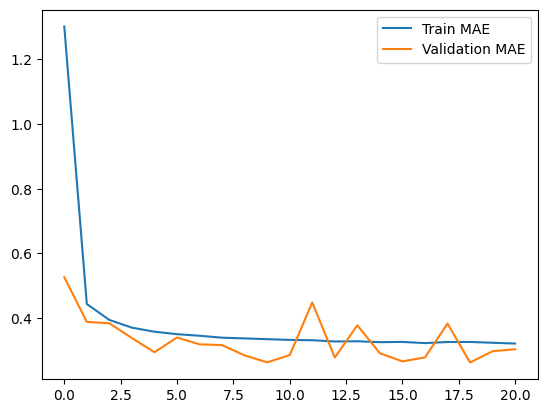

In [ ]:
plt.plot(history.history["mae"], label = "Train MAE")
plt.plot(history.history["val_mae"], label = "Validation MAE")
plt.legend()

In [ ]:
model_mae = model.evaluate(X_test, y_test, verbose=0)

print(f'Model Ortalama Mutlak Hatası {model_mae[1]:.4f}')

Model Mean Absolute Error 0.2887


## (3) 💻 Temel model karşılaştırması

> ❗️ **Önemli hatırlatma** ❗️ 
>  
> ***Derin Öğrenme modellerinizi ve daha genel olarak herhangi bir Makine Öğrenimi modelini her zaman bir temel modelle karşılaştırmayı unutmayın.***

🧑🏻‍🏫 Amacımızın çalışanların 11. yıl maaşını tahmin etmek olduğunu hatırlayın. Bu bir ***Regresyon görevi***dir. Hangi temel modeli oluşturabiliriz? 
1. Geleneksel bir regresyon modeli durumunda, `y_test` için temel tahmin **`y_train`'in ortalamasını tahmin etmektir**... ancak bu seçenek zamana bağlı seriler için alakasız olabilir. Teorik olarak, birinin maaşı yıllar boyunca artması gerekir!
2. Regresyon görevi için alternatif bir temel tahmin **son görülen değeri tahmin etmektir**

❓ **Sorular** ❓ 
* Maaşın 10. ve 11. yıl arasında sabit kaldığını tahmin eden temel modelin Ortalama Mutlak Hatasını hesaplayın
* Bu temel modeli RNN'inizle karşılaştırın

In [ ]:
# Sonraki maaşı tahmin etmek için X'teki son maaşı kullanma
y_test_baseline = X_test[:, -1, 0]
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))

print(f'Temel Model MAE = {mae_baseline:.3f}')
print("karşısında")
print(f'RNN MAE = {model_mae[1]:.3f}')

Baseline MAE = 0.624
vs.
RNN MAE = 0.289


👉 Bu soruyla takılıp kalırsanız, `(4) LSTM`'i deneyin ve sonra buraya geri dönün.

🧑🏻‍🏫 Gerekirse bir TA'ya sorun. Cevaba sadece bu soruları başarısız bir şekilde cevaplayamadığınızda bakın.

<details>
    <summary><i>Cevap</i></summary>


```python
# Sonraki maaşı tahmin etmek için X'teki son maaşı kullanma
y_test_baseline = X_test[:, -1, 0] 
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))   
```
    
</details>

😁 RNN'inizin temel modelden biraz daha iyi performans sergilediğini fark etmelisiniz.

## (4) 💻 LSTM: Uzun-Kısa Süreli Bellek

❓ **Sorular** ❓ 

* `SimpleRNN` katmanı yerine `LSTM` katmanı kullanan aynı modeli yazın
* Test seti üzerindeki performansınızı değerlendirin

In [ ]:
%%time

from keras.layers import LSTM
from keras.callbacks import EarlyStopping

model_LSTM = Sequential()
model_LSTM.add(normalizer)
model_LSTM.add(LSTM(units=20, activation='tanh'))
model_LSTM.add(Dense(10, activation='relu'))
model_LSTM.add(Dense(1, activation='linear'))

model_LSTM = compile_model(model_LSTM)

es = EarlyStopping(patience=5, restore_best_weights=True)

history_LSTM = model_LSTM.fit(X_train, y_train,
                              validation_split=0.2,
                              batch_size=32,
                              epochs=100,
                              callbacks=[es],verbose=1)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 31.4968 - mae: 2.9876 - val_loss: 4.3097 - val_mae: 0.8581
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.0082 - mae: 0.6859 - val_loss: 1.2239 - val_mae: 0.4094
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0408 - mae: 0.3824 - val_loss: 0.7182 - val_mae: 0.3025
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7991 - mae: 0.3305 - val_loss: 0.6076 - val_mae: 0.2805
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5707 - mae: 0.2997 - val_loss: 0.6146 - val_mae: 0.3447
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6246 - mae: 0.3056 - val_loss: 0.5837 - val_mae: 0.3071
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6269 - mae: 0.3013 - val_loss: 0.8583 - val_mae: 0.5486
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6121 - mae: 0.3023 - val_loss: 0.5160 - val_mae: 0.2735
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms

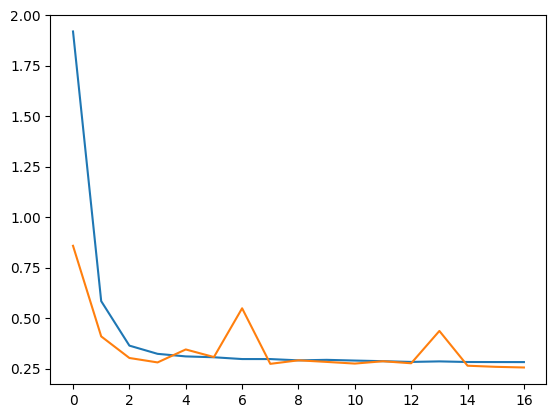

In [ ]:
plt.plot(history_LSTM.history["mae"])
plt.plot(history_LSTM.history["val_mae"])

In [ ]:
lstm_mae = model_LSTM.evaluate(X_test, y_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 0.7092 - mae: 0.3000


In [ ]:
print(f'Temel Model MAE = {mae_baseline:.3f}')
print("karşısında")
print(f'RNN MAE = {model_mae[1]:.3f}')
print("karşısında")
print(f'LSTM MAE = {lstm_mae[1]:.3f}')

Baseline MAE = 0.624
vs.
RNN MAE = 0.289
vs.
LSTM MAE = 0.317


💪 LSTM, daha düşük MAE ile SimpleRNN'den biraz daha iyi performans sergilemelidir.

🏁 Tebrikler! Sıralı veri üzerinde bir RNN'yi nasıl eğiteceğinizi biliyorsunuz.
 

💾 Notebook'unuzu git add/commit/push yapmayı unutmayın...

🚀 ... ve sonraki egzersize geçin!

---

<u>Not</u>: Üzerinde çalıştığınız diziler tamamen sahte. Benzer verileri eğitmeniz ve yeniden üretmeniz gerektiğinde, böyle bir veri setini simüle etmek için kullanılan fonksiyonları aşağıda bulabilirsiniz.

## 🛠 (Yardımcı Araçlar)

In [ ]:
def create_sequences(number):
    X, y = [], []

    for i in range(number):
        x_i, y_i = create_individual_sequence(10)
        X.append(x_i)
        y.append(y_i)

    return np.array(X), np.array(y)

def create_individual_sequence(length):
    company_sizes = []
    nb_persons = []
    salaries = []


    # Education level
    educ_level = [max(0, int(np.random.normal(10, 2)))]*length

    # Company size
    current_size = int(1 + np.random.beta(.4, 4)*500)
    for i in range(length):
        if not np.random.randint(4): # Change 1 out of 3 possibilities
            current_size = int(max(1, np.random.normal(current_size, 50)))
        company_sizes.append(current_size)

    # Number of persons
    nb_iter = np.random.beta(.15, 4)*300
    for i in range(length):
        if not np.random.randint(2): # Change 1 out of 2 possibilities
            R_1 = np.random.beta(0.5, 8)*3
            nb_iter = nb_iter + max(-2, R_1*company_sizes[i] + np.random.randint(-2, 2))
            nb_iter = max(0, nb_iter)
            nb_iter = int(min(company_sizes[i]-1, nb_iter))
        nb_persons.append(nb_iter)


    # Salary
    salary_iter = max(800, int(np.random.normal(1200, 300)+ 0.05*company_sizes[0] +  np.random.normal(40, 400)))
    salaries.append(salary_iter)
    for i in range(1, length + 1):
        R_1 = np.random.normal(100, 50)
        change_person = nb_persons[i-1] - nb_persons[i-2]
        change_company = max(0, company_sizes[i-1] - company_sizes[i-2])
        salary_iter = salary_iter + 0.05*change_company + change_person*R_1 + np.random.normal(100, 50)
        salary_iter = max(int(salary_iter), 500)

        salaries.append(salary_iter)

    y = salaries[-1]/1000
    salaries = [_/1000 for _ in salaries[:-1]]

    return np.array([salaries, nb_persons, company_sizes]).T, y

In [ ]:
#X, y = create_sequences(25000)

#np.save('X', X.astype(np.float32))
#np.save('y', y)